In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from arch import arch_model

# Locate the project.
cwd = Path.cwd().resolve()

project_root = next(
    (
        folder
        for folder in [cwd, *cwd.parents]
        if (folder / "requirements.txt").is_file()
        and (folder / "data" / "processed").is_dir()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not locate the project folder.")

# Load the prepared dataset.
data = pd.read_csv(
    project_root / "data" / "processed"
    / "ftse100_modelling_dataset.csv",
    index_col="Date",
    parse_dates=["Date"],
)

# Estimate using the initial training period only.
r_train = data.loc[
    "2000-01-01":"2017-12-31", "return_pct"
].copy()

tables_folder = project_root / "outputs" / "tables"
tables_folder.mkdir(parents=True, exist_ok=True)

assert np.isfinite(r_train.to_numpy()).all()

print("Training observations:", len(r_train))
print("Training ends:", r_train.index.max().date())

Training observations: 4548
Training ends: 2017-12-29


In [2]:
garch_model = arch_model(
    r_train,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=0,
    q=1,
    power=2.0,
    dist="t",
    rescale=False,
)

garch_fit = garch_model.fit(
    update_freq=0,
    disp="off",
    cov_type="robust",
)

print(garch_fit.summary())

print("\nConvergence flag:", garch_fit.convergence_flag)
print("Optimizer message:", garch_fit.optimization_result.message)

if garch_fit.convergence_flag != 0:
    raise RuntimeError(
        "The optimizer did not converge successfully. "
        "Inspect the message before using these estimates."
    )

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6262.34
Distribution:      Standardized Student's t   AIC:                           12534.7
Method:                  Maximum Likelihood   BIC:                           12566.8
                                              No. Observations:                 4548
Date:                      Sat, Sep 26 2026   Df Residuals:                     4547
Time:                              10:57:05   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [3]:
garch_parameters = pd.DataFrame({
    "estimate": garch_fit.params,
    "robust_standard_error": garch_fit.std_err,
    "p_value": garch_fit.pvalues,
})

garch_parameters.to_csv(
    tables_folder / "garch_t_training_parameters.csv",
    index_label="Parameter",
)

persistence = (
    garch_fit.params["alpha[1]"]
    + garch_fit.params["beta[1]"]
)

print(f"Alpha + beta: {persistence:.6f}")

Alpha + beta: 0.991329


In [4]:
print("Convergence flag:", garch_fit.convergence_flag)
print("Optimizer message:", garch_fit.optimization_result.message)

if garch_fit.convergence_flag != 0:
    raise RuntimeError("Resolve the convergence issue before continuing.")

z_garch = garch_fit.std_resid.copy()

assert np.isfinite(z_garch.to_numpy()).all()

print("Standardised residual observations:", len(z_garch))
print(f"Mean: {z_garch.mean():.4f}")
print(f"Variance: {z_garch.var(ddof=1):.4f}")

Convergence flag: 0
Optimizer message: Optimization terminated successfully
Standardised residual observations: 4548
Mean: -0.0507
Variance: 0.9959


In [5]:
from statsmodels.stats.diagnostic import acorr_ljungbox

diagnostic_lags = [5, 10, 20]

garch_lb = pd.concat(
    {
        "Standardised residuals": acorr_ljungbox(
            z_garch,
            lags=diagnostic_lags,
            model_df=0,
            return_df=True,
        ),
        "Squared standardised residuals": acorr_ljungbox(
            z_garch ** 2,
            lags=diagnostic_lags,
            model_df=0,
            return_df=True,
        ),
    },
    names=["Series", "Lag"],
)

display(
    garch_lb.style.format({
        "lb_stat": "{:.3f}",
        "lb_pvalue": "{:.3e}",
    })
)

garch_lb.to_csv(
    tables_folder / "garch_t_residual_ljung_box.csv"
)

In [6]:
garch_arch_rows = []

for lag in diagnostic_lags:
    result = garch_fit.arch_lm_test(
        lags=lag,
        standardized=True,
    )

    garch_arch_rows.append({
        "Lag": lag,
        "LM statistic": result.stat,
        "LM p-value": result.pval,
    })

garch_arch = pd.DataFrame(garch_arch_rows).set_index("Lag")

display(
    garch_arch.style.format({
        "LM statistic": "{:.3f}",
        "LM p-value": "{:.3e}",
    })
)

garch_arch.to_csv(
    tables_folder / "garch_t_standardised_arch_lm.csv"
)

,LM statistic,LM p-value
Lag,,
5,4.807,4.399e-01
10,12.545,2.502e-01
20,30.679,5.957e-02


In [7]:
gjr_model = arch_model(
    r_train,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=1,
    q=1,
    power=2.0,
    dist="t",
    rescale=False,
)

gjr_fit = gjr_model.fit(
    update_freq=0,
    disp="off",
    cov_type="robust",
)

print(gjr_fit.summary())

print("\nConvergence flag:", gjr_fit.convergence_flag)
print("Optimizer message:", gjr_fit.optimization_result.message)

if gjr_fit.convergence_flag != 0:
    raise RuntimeError(
        "Resolve the convergence issue before using these estimates."
    )

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                   return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -6177.24
Distribution:      Standardized Student's t   AIC:                           12366.5
Method:                  Maximum Likelihood   BIC:                           12405.0
                                              No. Observations:                 4548
Date:                      Sat, Sep 26 2026   Df Residuals:                     4547
Time:                              10:57:06   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

In [8]:
gjr_alpha = gjr_fit.params["alpha[1]"]
gjr_gamma = gjr_fit.params["gamma[1]"]
gjr_beta = gjr_fit.params["beta[1]"]

gjr_persistence = gjr_alpha + gjr_beta + 0.5 * gjr_gamma

print(f"Positive-shock coefficient: {gjr_alpha:.6f}")
print(f"Negative-shock coefficient: {gjr_alpha + gjr_gamma:.6f}")
print(f"Asymmetry coefficient (gamma): {gjr_gamma:.6f}")
print(f"GJR persistence: {gjr_persistence:.6f}")

gjr_parameters = pd.DataFrame({
    "estimate": gjr_fit.params,
    "robust_standard_error": gjr_fit.std_err,
    "p_value": gjr_fit.pvalues,
})

gjr_parameters.to_csv(
    tables_folder / "gjr_garch_t_training_parameters.csv",
    index_label="Parameter",
)

Positive-shock coefficient: 0.000000
Negative-shock coefficient: 0.178931
Asymmetry coefficient (gamma): 0.178931
GJR persistence: 0.983861


In [9]:
fit_comparison = pd.DataFrame({
    "GARCH-t": {
        "Observations": garch_fit.nobs,
        "Parameters": garch_fit.num_params,
        "Log-likelihood": garch_fit.loglikelihood,
        "AIC": garch_fit.aic,
        "BIC": garch_fit.bic,
    },
    "GJR-GARCH-t": {
        "Observations": gjr_fit.nobs,
        "Parameters": gjr_fit.num_params,
        "Log-likelihood": gjr_fit.loglikelihood,
        "AIC": gjr_fit.aic,
        "BIC": gjr_fit.bic,
    },
}).T

display(fit_comparison.round(3))

fit_comparison.to_csv(
    tables_folder / "training_model_comparison.csv",
    index_label="Model",
)

,Observations,Parameters,Log-likelihood,AIC,BIC
GARCH-t,4548.0,5.0,-6262.343,12534.685,12566.797
GJR-GARCH-t,4548.0,6.0,-6177.241,12366.483,12405.017


In [10]:
z_gjr = gjr_fit.std_resid.copy()

assert np.isfinite(z_gjr.to_numpy()).all()

print(f"Standardised residual mean: {z_gjr.mean():.4f}")
print(f"Standardised residual variance: {z_gjr.var(ddof=1):.4f}")

gjr_lb = pd.concat(
    {
        "Standardised residuals": acorr_ljungbox(
            z_gjr,
            lags=diagnostic_lags,
            model_df=0,
            return_df=True,
        ),
        "Squared standardised residuals": acorr_ljungbox(
            z_gjr ** 2,
            lags=diagnostic_lags,
            model_df=0,
            return_df=True,
        ),
    },
    names=["Series", "Lag"],
)

gjr_arch_rows = []

for lag in diagnostic_lags:
    result = gjr_fit.arch_lm_test(
        lags=lag,
        standardized=True,
    )

    gjr_arch_rows.append({
        "Lag": lag,
        "LM statistic": result.stat,
        "LM p-value": result.pval,
    })

gjr_arch = pd.DataFrame(gjr_arch_rows).set_index("Lag")

gjr_lb.to_csv(
    tables_folder / "gjr_garch_t_residual_ljung_box.csv"
)

gjr_arch.to_csv(
    tables_folder / "gjr_garch_t_standardised_arch_lm.csv"
)

Standardised residual mean: -0.0183
Standardised residual variance: 1.0002


In [11]:
diagnostic_comparison = pd.concat(
    {
        "GARCH-t": pd.DataFrame({
            "LB residual p-value":
                garch_lb.loc["Standardised residuals", "lb_pvalue"],
            "LB squared residual p-value":
                garch_lb.loc[
                    "Squared standardised residuals", "lb_pvalue"
                ],
            "ARCH-LM p-value": garch_arch["LM p-value"],
        }),
        "GJR-GARCH-t": pd.DataFrame({
            "LB residual p-value":
                gjr_lb.loc["Standardised residuals", "lb_pvalue"],
            "LB squared residual p-value":
                gjr_lb.loc[
                    "Squared standardised residuals", "lb_pvalue"
                ],
            "ARCH-LM p-value": gjr_arch["LM p-value"],
        }),
    },
    names=["Model", "Lag"],
)

display(diagnostic_comparison.style.format("{:.4f}"))

diagnostic_comparison.to_csv(
    tables_folder / "training_residual_diagnostic_comparison.csv"
)

In [12]:
egarch_model = arch_model(
    r_train,
    mean="Constant",
    vol="EGARCH",
    p=1,
    o=1,
    q=1,
    dist="t",
    rescale=False,
)

egarch_fit = egarch_model.fit(
    update_freq=0,
    disp="off",
    cov_type="robust",
    options={"maxiter": 1000},
)

print(egarch_fit.summary())

print("\nConvergence flag:", egarch_fit.convergence_flag)
print("Optimizer message:", egarch_fit.optimization_result.message)

if egarch_fit.convergence_flag != 0:
    raise RuntimeError(
        "Resolve the convergence issue before using these estimates."
    )

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                   return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -6168.46
Distribution:      Standardized Student's t   AIC:                           12348.9
Method:                  Maximum Likelihood   BIC:                           12387.5
                                              No. Observations:                 4548
Date:                      Sat, Sep 26 2026   Df Residuals:                     4547
Time:                              10:57:06   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

In [13]:
egarch_parameters = pd.DataFrame({
    "estimate": egarch_fit.params,
    "robust_standard_error": egarch_fit.std_err,
    "p_value": egarch_fit.pvalues,
})

display(egarch_parameters.round(6))

egarch_parameters.to_csv(
    tables_folder / "egarch_t_training_parameters.csv",
    index_label="Parameter",
)

print(
    "Asymmetry coefficient (gamma):",
    f"{egarch_fit.params['gamma[1]']:.6f}",
)

print(
    "Log-variance persistence (beta):",
    f"{egarch_fit.params['beta[1]']:.6f}",
)

,estimate,robust_standard_error,p_value
mu,0.006980,0.011869,0.556492
omega,-0.002421,0.002544,0.341180
alpha[1],0.119762,0.015062,0.000000
gamma[1],-0.138569,0.011375,0.000000
beta[1],0.983045,0.003113,0.000000
nu,12.450198,2.092832,0.000000


Asymmetry coefficient (gamma): -0.138569
Log-variance persistence (beta): 0.983045


In [14]:
fitted_models = {
    "GARCH-t": garch_fit,
    "GJR-GARCH-t": gjr_fit,
    "EGARCH-t": egarch_fit,
}

fit_comparison = pd.DataFrame({
    name: {
        "Observations": fitted.nobs,
        "Parameters": fitted.num_params,
        "Log-likelihood": fitted.loglikelihood,
        "AIC": fitted.aic,
        "BIC": fitted.bic,
    }
    for name, fitted in fitted_models.items()
}).T

display(fit_comparison.round(3))

fit_comparison.to_csv(
    tables_folder / "training_model_comparison.csv",
    index_label="Model",
)

,Observations,Parameters,Log-likelihood,AIC,BIC
GARCH-t,4548.0,5.0,-6262.343,12534.685,12566.797
GJR-GARCH-t,4548.0,6.0,-6177.241,12366.483,12405.017
EGARCH-t,4548.0,6.0,-6168.464,12348.929,12387.463


In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox

diagnostic_lags = [5, 10, 20]

z_egarch = egarch_fit.std_resid.copy()

assert len(z_egarch) == len(r_train)
assert np.isfinite(z_egarch.to_numpy()).all()

print("Standardised residual observations:", len(z_egarch))
print("Standardised residual mean:", round(z_egarch.mean(), 4))
print("Standardised residual variance:", round(z_egarch.var(ddof=1), 4))

egarch_lb = pd.concat(
    {
        "Standardised residuals": acorr_ljungbox(
            z_egarch,
            lags=diagnostic_lags,
            model_df=0,
            return_df=True,
        ),
        "Squared standardised residuals": acorr_ljungbox(
            z_egarch**2,
            lags=diagnostic_lags,
            model_df=0,
            return_df=True,
        ),
    },
    names=["Series", "Lag"],
)

arch_results = {}

for lag in diagnostic_lags:
    result = egarch_fit.arch_lm_test(
        lags=lag,
        standardized=True,
    )
    arch_results[lag] = {
        "LM statistic": result.stat,
        "LM p-value": result.pval,
    }

egarch_arch = pd.DataFrame.from_dict(
    arch_results,
    orient="index",
)
egarch_arch.index.name = "Lag"

display(egarch_lb)
display(egarch_arch)

egarch_lb.to_csv(
    tables_folder / "egarch_t_residual_ljung_box.csv"
)
egarch_arch.to_csv(
    tables_folder / "egarch_t_standardised_arch_lm.csv"
)

Standardised residual observations: 4548
Standardised residual mean: -0.0159
Standardised residual variance: 1.0012


lb_stat  lb_pvalue
Series                         Lag                      
Standardised residuals         5     6.296177   0.278457
                               10    6.942282   0.730882
                               20   15.978819   0.717937
Squared standardised residuals 5     6.306708   0.277508
                               10   12.299371   0.265520
                               20   26.546742   0.148504

,LM statistic,LM p-value
Lag,,
5,6.515048,0.259275
10,12.222111,0.270466
20,25.653376,0.177567


In [16]:
model_diagnostics = {
    "GARCH-t": (garch_lb, garch_arch),
    "GJR-GARCH-t": (gjr_lb, gjr_arch),
    "EGARCH-t": (egarch_lb, egarch_arch),
}

diagnostic_comparison = pd.concat(
    {
        name: pd.DataFrame({
            "LB residual p-value": lb.loc[
                "Standardised residuals", "lb_pvalue"
            ],
            "LB squared residual p-value": lb.loc[
                "Squared standardised residuals", "lb_pvalue"
            ],
            "ARCH-LM p-value": arch_results["LM p-value"],
        })
        for name, (lb, arch_results) in model_diagnostics.items()
    },
    names=["Model", "Lag"],
)

display(diagnostic_comparison.style.format("{:.4f}"))

diagnostic_comparison.to_csv(
    tables_folder / "training_residual_diagnostic_comparison.csv"
)

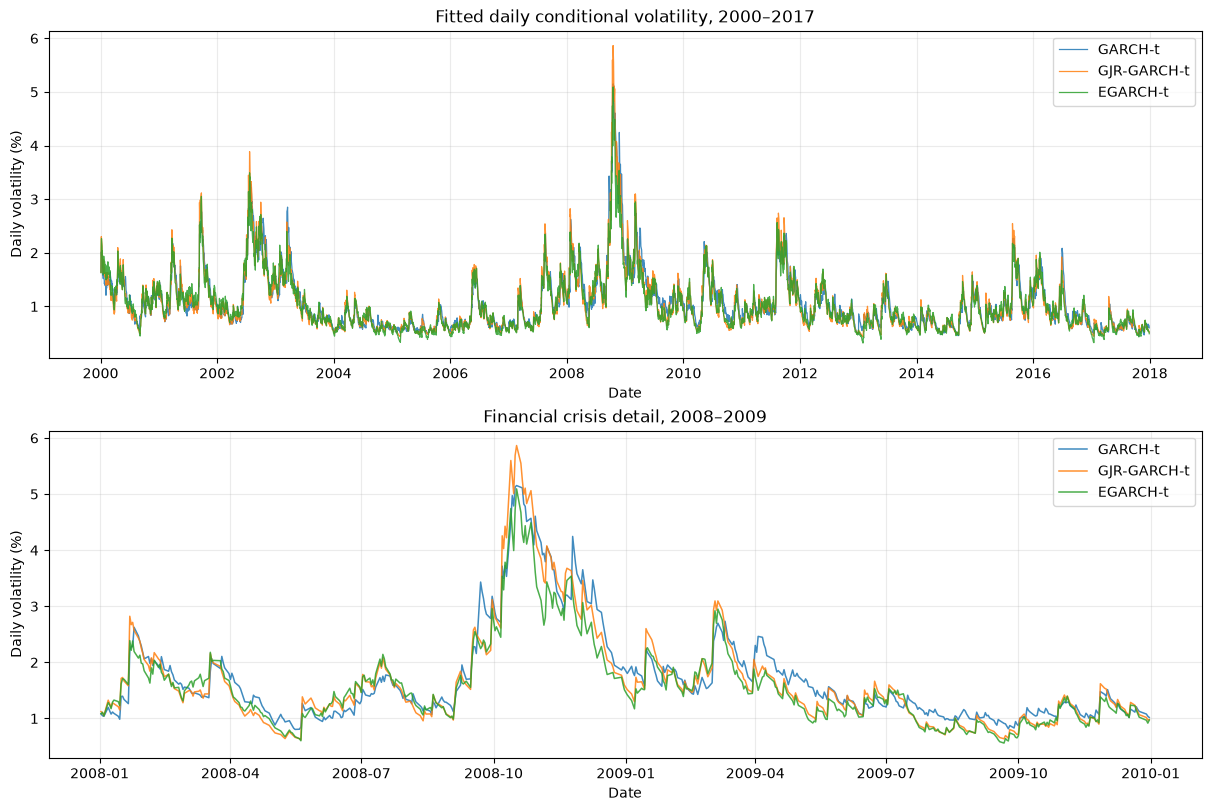

In [17]:
import matplotlib.pyplot as plt

figures_folder = project_root / "outputs" / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

fitted_models = {
    "GARCH-t": garch_fit,
    "GJR-GARCH-t": gjr_fit,
    "EGARCH-t": egarch_fit,
}

conditional_volatility = pd.DataFrame({
    name: fitted.conditional_volatility
    for name, fitted in fitted_models.items()
})

assert conditional_volatility.index.equals(r_train.index)
assert np.isfinite(conditional_volatility.to_numpy()).all()
assert (conditional_volatility > 0).all().all()

colors = {
    "GARCH-t": "tab:blue",
    "GJR-GARCH-t": "tab:orange",
    "EGARCH-t": "tab:green",
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    constrained_layout=True,
)

for name in conditional_volatility.columns:
    axes[0].plot(
        conditional_volatility.index,
        conditional_volatility[name],
        label=name,
        color=colors[name],
        linewidth=0.9,
        alpha=0.85,
    )

    crisis = conditional_volatility.loc["2008":"2009", name]
    axes[1].plot(
        crisis.index,
        crisis,
        label=name,
        color=colors[name],
        linewidth=1.1,
        alpha=0.85,
    )

axes[0].set_title("Fitted daily conditional volatility, 2000–2017")
axes[1].set_title("Financial crisis detail, 2008–2009")

for ax in axes:
    ax.set_ylabel("Daily volatility (%)")
    ax.set_xlabel("Date")
    ax.grid(alpha=0.25)
    ax.legend()

fig.savefig(
    figures_folder / "training_conditional_volatility.png",
    dpi=300,
    bbox_inches="tight",
)

conditional_volatility.to_csv(
    tables_folder / "training_conditional_volatility.csv",
    index_label="Date",
)

plt.show()

In [18]:
forecast_origin = r_train.index[-1]
forecast_date = data.loc["2018-01-01":].index[0]

assert forecast_origin == pd.Timestamp("2017-12-29")
assert forecast_date == pd.Timestamp("2018-01-02")

first_forecast_rows = []

for name, fitted in fitted_models.items():
    assert fitted.convergence_flag == 0
    assert fitted.resid.index.equals(r_train.index)

    forecast = fitted.forecast(
        horizon=1,
        method="analytic",
        align="origin",
        reindex=False,
    )

    assert forecast.variance.index[-1] == forecast_origin

    variance_forecast = float(
        forecast.variance.iloc[-1]["h.1"]
    )

    assert np.isfinite(variance_forecast)
    assert variance_forecast > 0

    first_forecast_rows.append({
        "Model": name,
        "forecast_origin": forecast_origin,
        "forecast_date": forecast_date,
        "variance_forecast": variance_forecast,
        "volatility_forecast_pct": np.sqrt(variance_forecast),
    })

first_forecasts = pd.DataFrame(
    first_forecast_rows
).set_index("Model")

display(first_forecasts.round(6))

first_forecasts.to_csv(
    tables_folder / "first_out_of_sample_forecasts.csv",
    index_label="Model",
)

/var/folders/04/dz2_971d2_q7pyt7jqddhvzh0000gn/T/ipykernel_7071/2645071138.py:41: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(first_forecasts.round(6))


,forecast_origin,forecast_date,variance_forecast,volatility_forecast_pct
Model,,,,
GARCH-t,2017-12-29,2018-01-02,0.402641,0.634540
GJR-GARCH-t,2017-12-29,2018-01-02,0.256592,0.506549
EGARCH-t,2017-12-29,2018-01-02,0.216570,0.465371


In [19]:
from time import perf_counter

returns = data["return_pct"].copy()
oos_dates = returns.loc["2018-01-01":].index

assert returns.index.is_monotonic_increasing
assert returns.index.is_unique
assert np.isfinite(returns.to_numpy()).all()
assert len(oos_dates) == 2188

model_specs = {
    "GARCH-t": {"vol": "GARCH", "p": 1, "o": 0, "q": 1},
    "GJR-GARCH-t": {"vol": "GARCH", "p": 1, "o": 1, "q": 1},
    "EGARCH-t": {"vol": "EGARCH", "p": 1, "o": 1, "q": 1},
}

# Zero-mean EWMA benchmark:
# h[t] = lambda * h[t-1] + (1-lambda) * r[t-1]^2
ewma_lambda = 0.94

ewma_variance = pd.Series(
    np.nan,
    index=returns.index,
    name="EWMA",
)

# Initialize using the first 20 training returns.
# The first forecast this seed supports is for observation 21.
seed_length = 20
h = float(returns.iloc[:seed_length].pow(2).mean())

for position in range(seed_length, len(returns)):
    # Store today's prediction BEFORE observing today's return.
    ewma_variance.iloc[position] = h

    # Today's return becomes available for tomorrow's prediction.
    h = (
        ewma_lambda * h
        + (1 - ewma_lambda) * returns.iloc[position] ** 2
    )

print("Out-of-sample dates:", len(oos_dates))
print("First forecast date:", oos_dates[0].date())
print("Last forecast date:", oos_dates[-1].date())

Out-of-sample dates: 2188
First forecast date: 2018-01-02
Last forecast date: 2026-08-28


In [20]:
forecast_rows = []
started = perf_counter()

checkpoint_path = (
    tables_folder / "expanding_window_forecasts_checkpoint.csv"
)

for number, forecast_date in enumerate(oos_dates, start=1):
    position = returns.index.get_loc(forecast_date)

    # iloc excludes position itself: the target return is unavailable.
    history = returns.iloc[:position]
    forecast_origin = history.index[-1]

    assert forecast_origin < forecast_date

    for name, specification in model_specs.items():
        model = arch_model(
            history,
            mean="Constant",
            dist="t",
            rescale=False,
            **specification,
        )

        fitted = model.fit(
            update_freq=0,
            disp="off",
            options={"maxiter": 1000},
        )

        if fitted.convergence_flag != 0:
            pd.DataFrame(forecast_rows).to_csv(
                checkpoint_path, index=False
            )
            raise RuntimeError(
                f"{name} failed to converge for "
                f"{forecast_date.date()}: "
                f"{fitted.optimization_result.message}"
            )

        forecast = fitted.forecast(
            horizon=1,
            method="analytic",
            align="origin",
            reindex=False,
        )

        assert forecast.variance.index[-1] == forecast_origin
        h_forecast = float(forecast.variance.iloc[-1]["h.1"])

        if not np.isfinite(h_forecast) or h_forecast <= 0:
            raise RuntimeError(
                f"Invalid variance forecast: {name}, "
                f"{forecast_date.date()}, {h_forecast}"
            )

        forecast_rows.append({
            "forecast_date": forecast_date,
            "forecast_origin": forecast_origin,
            "Model": name,
            "training_observations": len(history),
            "variance_forecast": h_forecast,
            "convergence_flag": fitted.convergence_flag,
        })

    forecast_rows.append({
        "forecast_date": forecast_date,
        "forecast_origin": forecast_origin,
        "Model": "EWMA",
        "training_observations": len(history),
        "variance_forecast": float(
            ewma_variance.loc[forecast_date]
        ),
        "convergence_flag": np.nan,  # No optimizer for EWMA.
    })

    if number % 100 == 0 or number == len(oos_dates):
        pd.DataFrame(forecast_rows).to_csv(
            checkpoint_path, index=False
        )
        elapsed_minutes = (perf_counter() - started) / 60
        print(
            f"{number}/{len(oos_dates)} dates completed "
            f"| {elapsed_minutes:.1f} minutes"
        )

forecast_audit = pd.DataFrame(forecast_rows)

variance_forecasts = forecast_audit.pivot(
    index="forecast_date",
    columns="Model",
    values="variance_forecast",
).reindex(columns=[*model_specs, "EWMA"])

variance_forecasts.index.name = "Date"
variance_forecasts.columns.name = None

100/2188 dates completed | 0.1 minutes
200/2188 dates completed | 0.3 minutes
300/2188 dates completed | 0.4 minutes
400/2188 dates completed | 0.6 minutes
500/2188 dates completed | 0.7 minutes
600/2188 dates completed | 0.9 minutes
700/2188 dates completed | 1.0 minutes
800/2188 dates completed | 1.1 minutes
900/2188 dates completed | 1.3 minutes
1000/2188 dates completed | 1.4 minutes
1100/2188 dates completed | 1.6 minutes
1200/2188 dates completed | 1.7 minutes
1300/2188 dates completed | 1.9 minutes
1400/2188 dates completed | 2.0 minutes
1500/2188 dates completed | 2.2 minutes
1600/2188 dates completed | 2.3 minutes
1700/2188 dates completed | 2.5 minutes
1800/2188 dates completed | 2.6 minutes
1900/2188 dates completed | 2.8 minutes
2000/2188 dates completed | 2.9 minutes
2100/2188 dates completed | 3.1 minutes
2188/2188 dates completed | 3.2 minutes


In [21]:
assert variance_forecasts.index.equals(oos_dates)
assert variance_forecasts.shape == (2188, 4)
assert np.isfinite(variance_forecasts.to_numpy()).all()
assert (variance_forecasts > 0).all().all()

# Confirm the full loop reproduces the first forecasts we checked.
for name in model_specs:
    np.testing.assert_allclose(
        variance_forecasts.loc[oos_dates[0], name],
        first_forecasts.loc[name, "variance_forecast"],
        rtol=1e-5,
        atol=1e-8,
    )

variance_forecasts.to_csv(
    tables_folder / "expanding_window_variance_forecasts.csv"
)
forecast_audit.to_csv(
    tables_folder / "expanding_window_forecast_audit.csv",
    index=False,
)

display(variance_forecasts.head().round(6))
print("Forecast table shape:", variance_forecasts.shape)
print("Missing forecasts:", variance_forecasts.isna().sum().sum())

,GARCH-t,GJR-GARCH-t,EGARCH-t,EWMA
Date,,,,
2018-01-02,0.402641,0.256592,0.216570,0.300530
2018-01-03,0.403887,0.296632,0.269779,0.298581
2018-01-04,0.378045,0.282269,0.247308,0.286076
2018-01-05,0.356488,0.269398,0.226737,0.275162
2018-01-08,0.340279,0.257887,0.207716,0.266736


Forecast table shape: (2188, 4)
Missing forecasts: 0


In [22]:
# Match each forecast with the squared return on its TARGET date.
variance_proxy = data.loc[
    variance_forecasts.index, "squared_return"
].copy()

assert variance_proxy.index.equals(variance_forecasts.index)
assert np.isfinite(variance_proxy.to_numpy()).all()
assert (variance_proxy >= 0).all()

qlike_losses = pd.DataFrame(index=variance_forecasts.index)
squared_errors = pd.DataFrame(index=variance_forecasts.index)

for model_name in variance_forecasts.columns:
    h = variance_forecasts[model_name]

    qlike_losses[model_name] = np.log(h) + variance_proxy / h
    squared_errors[model_name] = (variance_proxy - h) ** 2

assert np.isfinite(qlike_losses.to_numpy()).all()
assert np.isfinite(squared_errors.to_numpy()).all()

print("Evaluation observations:", len(variance_proxy))
print("Zero squared returns:", variance_proxy.eq(0).sum())

Evaluation observations: 2188
Zero squared returns: 1


In [23]:
performance = pd.DataFrame({
    "Observations": qlike_losses.count(),
    "Mean QLIKE": qlike_losses.mean(),
    "MSE": squared_errors.mean(),
})

performance["RMSE"] = np.sqrt(performance["MSE"])

# Positive values mean the model beats EWMA.
performance["QLIKE gain vs EWMA"] = (
    performance.loc["EWMA", "Mean QLIKE"]
    - performance["Mean QLIKE"]
)

performance["MSE reduction vs EWMA (%)"] = 100 * (
    1 - performance["MSE"] / performance.loc["EWMA", "MSE"]
)

performance = performance.sort_values("Mean QLIKE")
performance.index.name = "Model"

display(
    performance.style.format({
        "Observations": "{:.0f}",
        "Mean QLIKE": "{:.6f}",
        "MSE": "{:.6f}",
        "RMSE": "{:.6f}",
        "QLIKE gain vs EWMA": "{:.6f}",
        "MSE reduction vs EWMA (%)": "{:.2f}",
    })
)

performance.to_csv(
    tables_folder / "oos_performance_squared_returns.csv"
)

qlike_losses.to_csv(
    tables_folder / "oos_daily_qlike_squared_returns.csv",
    index_label="Date",
)

squared_errors.to_csv(
    tables_folder / "oos_daily_squared_errors.csv",
    index_label="Date",
)

,Observations,Mean QLIKE,MSE,RMSE,QLIKE gain vs EWMA,MSE reduction vs EWMA (%)
Model,,,,,,
EGARCH-t,2188,0.575760,13.916075,3.730426,0.080996,6.33
GJR-GARCH-t,2188,0.584627,14.622742,3.823969,0.072129,1.57
GARCH-t,2188,0.608455,14.519910,3.810500,0.048301,2.27
EWMA,2188,0.656756,14.856511,3.854414,0.000000,0.00


In [24]:
import statsmodels.api as sm
from itertools import combinations

# All six pairs, rather than only comparisons involving the winner.
comparison_order = [
    "EWMA",
    "GARCH-t",
    "GJR-GARCH-t",
    "EGARCH-t",
]

comparison_rows = []

for reference, model_name in combinations(comparison_order, 2):
    difference = (
        qlike_losses[reference] - qlike_losses[model_name]
    ).to_numpy()

    assert np.isfinite(difference).all()

    for hac_lags in [5, 10, 20]:
        result = sm.OLS(
            difference,
            np.ones((len(difference), 1)),
        ).fit(
            cov_type="HAC",
            cov_kwds={
                "maxlags": hac_lags,
                "kernel": "bartlett",
                "use_correction": True,
            },
            use_t=False,
        )

        lower, upper = result.conf_int(alpha=0.05)[0]

        comparison_rows.append({
            "Model": model_name,
            "Reference": reference,
            "HAC lags": hac_lags,
            "Mean QLIKE gain": result.params[0],
            "HAC standard error": result.bse[0],
            "95% CI lower": lower,
            "95% CI upper": upper,
            "Two-sided p-value": result.pvalues[0],
        })

qlike_comparisons = pd.DataFrame(comparison_rows)

primary_comparisons = qlike_comparisons.loc[
    qlike_comparisons["HAC lags"].eq(10)
].copy()

display(
    primary_comparisons
    .set_index(["Model", "Reference"])
    .drop(columns="HAC lags")
    .style.format("{:.6f}")
)

qlike_comparisons.to_csv(
    tables_folder / "oos_qlike_pairwise_hac.csv",
    index=False,
)

In [25]:
hac_sensitivity = qlike_comparisons.pivot(
    index=["Model", "Reference"],
    columns="HAC lags",
    values="Two-sided p-value",
).reindex(columns=[5, 10, 20])

display(hac_sensitivity.style.format("{:.4f}"))

hac_sensitivity.to_csv(
    tables_folder / "oos_qlike_hac_lag_sensitivity.csv"
)

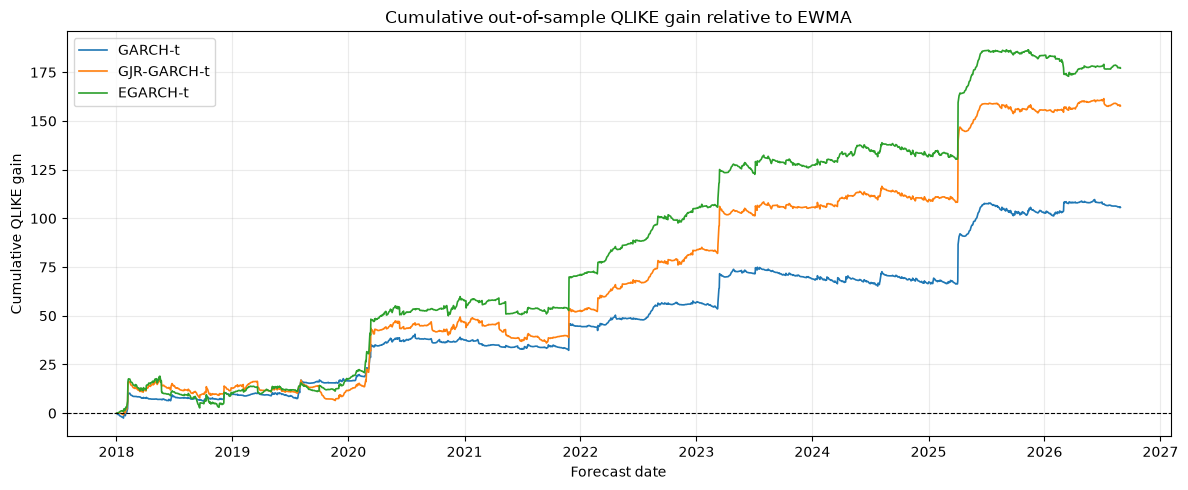

In [26]:
daily_qlike_gains = pd.DataFrame({
    name: qlike_losses["EWMA"] - qlike_losses[name]
    for name in ["GARCH-t", "GJR-GARCH-t", "EGARCH-t"]
})

cumulative_qlike_gains = daily_qlike_gains.cumsum()

fig, ax = plt.subplots(figsize=(12, 5))

for name in cumulative_qlike_gains.columns:
    ax.plot(
        cumulative_qlike_gains.index,
        cumulative_qlike_gains[name],
        label=name,
        color=colors[name],
        linewidth=1.2,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative out-of-sample QLIKE gain relative to EWMA")
ax.set_xlabel("Forecast date")
ax.set_ylabel("Cumulative QLIKE gain")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(
    figures_folder / "oos_cumulative_qlike_gain.png",
    dpi=300,
    bbox_inches="tight",
)

cumulative_qlike_gains.to_csv(
    tables_folder / "oos_cumulative_qlike_gain.csv",
    index_label="Date",
)

plt.show()

In [27]:
evaluation_dates = qlike_losses.index

period_masks = {
    "Full sample": np.ones(len(evaluation_dates), dtype=bool),
    "2020 only": evaluation_dates.year == 2020,
    "Excluding 2020": evaluation_dates.year != 2020,
}

period_tables = {}

for period_name, mask in period_masks.items():
    period_qlike = qlike_losses.loc[mask]
    period_errors = squared_errors.loc[mask]

    table = pd.DataFrame({
        "Observations": period_qlike.count(),
        "Mean QLIKE": period_qlike.mean(),
        "MSE": period_errors.mean(),
    })

    table["QLIKE gain vs EWMA"] = (
        table.loc["EWMA", "Mean QLIKE"] - table["Mean QLIKE"]
    )

    table["MSE reduction vs EWMA (%)"] = 100 * (
        1 - table["MSE"] / table.loc["EWMA", "MSE"]
    )

    period_tables[period_name] = table

period_performance = pd.concat(
    period_tables,
    names=["Period", "Model"],
)

display(
    period_performance.style.format({
        "Observations": "{:.0f}",
        "Mean QLIKE": "{:.4f}",
        "MSE": "{:.4f}",
        "QLIKE gain vs EWMA": "{:.4f}",
        "MSE reduction vs EWMA (%)": "{:.2f}",
    })
)

period_performance.to_csv(
    tables_folder / "oos_performance_2020_sensitivity.csv"
)

In [28]:
largest_gain_dates = (
    daily_qlike_gains["EGARCH-t"]
    .nlargest(10)
    .index
)

largest_gain_details = pd.DataFrame({
    "Return (%)": data.loc[largest_gain_dates, "return_pct"],
    "Squared return": variance_proxy.loc[largest_gain_dates],
    "EWMA variance forecast": variance_forecasts.loc[
        largest_gain_dates, "EWMA"
    ],
    "EGARCH variance forecast": variance_forecasts.loc[
        largest_gain_dates, "EGARCH-t"
    ],
    "EWMA QLIKE": qlike_losses.loc[largest_gain_dates, "EWMA"],
    "EGARCH QLIKE": qlike_losses.loc[largest_gain_dates, "EGARCH-t"],
    "EGARCH QLIKE gain": daily_qlike_gains.loc[
        largest_gain_dates, "EGARCH-t"
    ],
}).sort_values("EGARCH QLIKE gain", ascending=False)

display(largest_gain_details.round(4))

largest_gain_details.to_csv(
    tables_folder / "largest_daily_egarch_qlike_gains.csv",
    index_label="Date",
)

,Return (%),Squared return,EWMA variance forecast,EGARCH variance forecast,EWMA QLIKE,EGARCH QLIKE,EGARCH QLIKE gain
Date,,,,,,,
2025-04-04,-5.0792,25.7985,0.4381,0.8126,58.0653,31.5403,26.5250
2021-11-26,-3.7122,13.7803,0.2241,0.3135,59.9941,42.8024,17.1918
2018-02-06,-2.6749,7.1549,0.4190,1.0652,16.2078,6.7799,9.4279
2020-03-09,-7.9989,63.9818,3.0277,5.4588,22.2400,13.4181,8.8219
2020-03-12,-11.5117,132.5194,6.0273,9.9259,23.7828,15.6460,8.1368
2023-03-13,-2.6124,6.8248,0.3806,0.7080,16.9652,9.2947,7.6705
2023-03-15,-3.9066,15.2617,0.8027,1.2977,18.7924,12.0213,6.7711
2023-07-06,-2.1954,4.8196,0.3515,0.6559,12.6669,6.9266,5.7403
2020-02-24,-3.3944,11.5219,0.6026,0.8745,18.6131,13.0411,5.5721


In [29]:
parkinson_proxy = data.loc[
    variance_forecasts.index, "parkinson_var"
].copy()

assert parkinson_proxy.index.equals(variance_forecasts.index)
assert np.isfinite(parkinson_proxy.to_numpy()).all()
assert (parkinson_proxy >= 0).all()

parkinson_qlike = pd.DataFrame(index=variance_forecasts.index)
parkinson_squared_errors = pd.DataFrame(
    index=variance_forecasts.index
)

for model_name in variance_forecasts.columns:
    h = variance_forecasts[model_name]

    parkinson_qlike[model_name] = (
        np.log(h) + parkinson_proxy / h
    )
    parkinson_squared_errors[model_name] = (
        parkinson_proxy - h
    ) ** 2

assert np.isfinite(parkinson_qlike.to_numpy()).all()
assert np.isfinite(parkinson_squared_errors.to_numpy()).all()

parkinson_performance = pd.DataFrame({
    "Observations": parkinson_qlike.count(),
    "Mean QLIKE": parkinson_qlike.mean(),
    "MSE": parkinson_squared_errors.mean(),
})

parkinson_performance["QLIKE gain vs EWMA"] = (
    parkinson_performance.loc["EWMA", "Mean QLIKE"]
    - parkinson_performance["Mean QLIKE"]
)

parkinson_performance["MSE reduction vs EWMA (%)"] = 100 * (
    1
    - parkinson_performance["MSE"]
    / parkinson_performance.loc["EWMA", "MSE"]
)

parkinson_performance = parkinson_performance.sort_values(
    "Mean QLIKE"
)
parkinson_performance.index.name = "Model"

display(
    parkinson_performance.style.format({
        "Observations": "{:.0f}",
        "Mean QLIKE": "{:.6f}",
        "MSE": "{:.6f}",
        "QLIKE gain vs EWMA": "{:.6f}",
        "MSE reduction vs EWMA (%)": "{:.2f}",
    })
)

parkinson_performance.to_csv(
    tables_folder / "oos_performance_parkinson.csv"
)
parkinson_qlike.to_csv(
    tables_folder / "oos_daily_qlike_parkinson.csv",
    index_label="Date",
)
parkinson_squared_errors.to_csv(
    tables_folder / "oos_daily_squared_errors_parkinson.csv",
    index_label="Date",
)

,Observations,Mean QLIKE,MSE,QLIKE gain vs EWMA,MSE reduction vs EWMA (%)
Model,,,,,
EGARCH-t,2188,0.394605,2.260733,0.041676,30.59
GJR-GARCH-t,2188,0.408461,3.223349,0.027819,1.03
GARCH-t,2188,0.423537,2.806099,0.012743,13.84
EWMA,2188,0.436280,3.256885,0.000000,0.00


In [30]:
proxy_rankings = pd.DataFrame({
    "Squared-return QLIKE rank":
        performance["Mean QLIKE"].rank(method="min"),
    "Parkinson QLIKE rank":
        parkinson_performance["Mean QLIKE"].rank(method="min"),
    "Squared-return MSE rank":
        performance["MSE"].rank(method="min"),
    "Parkinson MSE rank":
        parkinson_performance["MSE"].rank(method="min"),
}).astype(int)

display(proxy_rankings)

proxy_rankings.to_csv(
    tables_folder / "oos_rankings_by_variance_proxy.csv",
    index_label="Model",
)

,Squared-return QLIKE rank,Parkinson QLIKE rank,Squared-return MSE rank,Parkinson MSE rank
Model,,,,
EGARCH-t,1,1,1,1
GJR-GARCH-t,2,2,3,3
GARCH-t,3,3,2,2
EWMA,4,4,4,4


In [31]:
normal_forecast_rows = []
normal_started = perf_counter()

normal_checkpoint = (
    tables_folder / "normal_forecasts_checkpoint.csv"
)

for number, forecast_date in enumerate(oos_dates, start=1):
    position = returns.index.get_loc(forecast_date)
    history = returns.iloc[:position]

    assert history.index[-1] < forecast_date

    for student_name, specification in model_specs.items():
        normal_name = student_name.removesuffix("-t") + "-Normal"

        model = arch_model(
            history,
            mean="Constant",
            dist="normal",  # Only the innovation distribution changes.
            rescale=False,
            **specification,
        )

        fitted = model.fit(
            update_freq=0,
            disp="off",
            options={"maxiter": 1000},
        )

        if fitted.convergence_flag != 0:
            pd.DataFrame(normal_forecast_rows).to_csv(
                normal_checkpoint, index=False
            )
            raise RuntimeError(
                f"{normal_name} failed for {forecast_date.date()}: "
                f"{fitted.optimization_result.message}"
            )

        forecast = fitted.forecast(
            horizon=1,
            method="analytic",
            align="origin",
            reindex=False,
        )

        assert forecast.variance.index[-1] == history.index[-1]

        h = float(forecast.variance.iloc[-1]["h.1"])

        if not np.isfinite(h) or h <= 0:
            raise RuntimeError(
                f"Invalid forecast: {normal_name}, "
                f"{forecast_date.date()}, {h}"
            )

        normal_forecast_rows.append({
            "forecast_date": forecast_date,
            "forecast_origin": history.index[-1],
            "Model": normal_name,
            "training_observations": len(history),
            "variance_forecast": h,
            "convergence_flag": fitted.convergence_flag,
        })

    if number % 100 == 0 or number == len(oos_dates):
        pd.DataFrame(normal_forecast_rows).to_csv(
            normal_checkpoint, index=False
        )
        print(
            f"{number}/{len(oos_dates)} dates completed "
            f"| {(perf_counter() - normal_started) / 60:.1f} minutes"
        )

normal_forecast_audit = pd.DataFrame(normal_forecast_rows)

normal_variance_forecasts = normal_forecast_audit.pivot(
    index="forecast_date",
    columns="Model",
    values="variance_forecast",
)

normal_variance_forecasts.index.name = "Date"
normal_variance_forecasts.columns.name = None

assert normal_variance_forecasts.index.equals(oos_dates)
assert normal_variance_forecasts.shape == (2188, 3)
assert np.isfinite(normal_variance_forecasts.to_numpy()).all()
assert (normal_variance_forecasts > 0).all().all()

normal_variance_forecasts.to_csv(
    tables_folder / "expanding_window_normal_variance_forecasts.csv"
)
normal_forecast_audit.to_csv(
    tables_folder / "expanding_window_normal_forecast_audit.csv",
    index=False,
)

100/2188 dates completed | 0.1 minutes
200/2188 dates completed | 0.2 minutes
300/2188 dates completed | 0.3 minutes
400/2188 dates completed | 0.4 minutes
500/2188 dates completed | 0.5 minutes
600/2188 dates completed | 0.6 minutes
700/2188 dates completed | 0.7 minutes
800/2188 dates completed | 0.8 minutes
900/2188 dates completed | 0.9 minutes
1000/2188 dates completed | 1.0 minutes
1100/2188 dates completed | 1.1 minutes
1200/2188 dates completed | 1.2 minutes
1300/2188 dates completed | 1.3 minutes
1400/2188 dates completed | 1.4 minutes
1500/2188 dates completed | 1.5 minutes
1600/2188 dates completed | 1.6 minutes
1700/2188 dates completed | 1.8 minutes
1800/2188 dates completed | 1.9 minutes
1900/2188 dates completed | 2.0 minutes
2000/2188 dates completed | 2.1 minutes
2100/2188 dates completed | 2.2 minutes
2188/2188 dates completed | 2.3 minutes


In [32]:
distribution_forecasts = pd.concat(
    [variance_forecasts, normal_variance_forecasts],
    axis=1,
)

distribution_qlike = pd.DataFrame(
    index=distribution_forecasts.index
)
distribution_mse = pd.DataFrame(
    index=distribution_forecasts.index
)

for name in distribution_forecasts.columns:
    h = distribution_forecasts[name]

    distribution_qlike[name] = np.log(h) + variance_proxy / h
    distribution_mse[name] = (variance_proxy - h) ** 2

distribution_performance = pd.DataFrame({
    "Observations": distribution_qlike.count(),
    "Mean QLIKE": distribution_qlike.mean(),
    "MSE": distribution_mse.mean(),
})

distribution_performance["QLIKE gain vs EWMA"] = (
    distribution_performance.loc["EWMA", "Mean QLIKE"]
    - distribution_performance["Mean QLIKE"]
)

distribution_performance["MSE reduction vs EWMA (%)"] = 100 * (
    1
    - distribution_performance["MSE"]
    / distribution_performance.loc["EWMA", "MSE"]
)

distribution_performance = distribution_performance.sort_values(
    "Mean QLIKE"
)
distribution_performance.index.name = "Model"

display(
    distribution_performance.style.format({
        "Observations": "{:.0f}",
        "Mean QLIKE": "{:.6f}",
        "MSE": "{:.6f}",
        "QLIKE gain vs EWMA": "{:.6f}",
        "MSE reduction vs EWMA (%)": "{:.2f}",
    })
)

distribution_performance.to_csv(
    tables_folder / "oos_distribution_sensitivity.csv"
)
distribution_qlike.to_csv(
    tables_folder / "oos_distribution_daily_qlike.csv",
    index_label="Date",
)

,Observations,Mean QLIKE,MSE,QLIKE gain vs EWMA,MSE reduction vs EWMA (%)
Model,,,,,
EGARCH-Normal,2188,0.573401,13.967423,0.083355,5.98
EGARCH-t,2188,0.575760,13.916075,0.080996,6.33
GJR-GARCH-Normal,2188,0.582973,14.526377,0.073783,2.22
GJR-GARCH-t,2188,0.584627,14.622742,0.072129,1.57
GARCH-Normal,2188,0.606777,14.501918,0.049979,2.39
GARCH-t,2188,0.608455,14.519910,0.048301,2.27
EWMA,2188,0.656756,14.856511,0.000000,0.00


In [33]:
rolling_window = 1260
rolling_rows = []
rolling_started = perf_counter()

rolling_checkpoint = (
    tables_folder / "rolling_1260_forecasts_checkpoint.csv"
)

assert returns.index.get_loc(oos_dates[0]) >= rolling_window

for number, forecast_date in enumerate(oos_dates, start=1):
    position = returns.index.get_loc(forecast_date)

    # Exactly 1,260 observations, excluding the forecast target.
    history = returns.iloc[position - rolling_window:position]

    assert len(history) == rolling_window
    assert history.index[-1] < forecast_date

    for name, specification in model_specs.items():
        model = arch_model(
            history,
            mean="Constant",
            dist="t",
            rescale=False,
            **specification,
        )

        fitted = model.fit(
            update_freq=0,
            disp="off",
            options={"maxiter": 1000},
        )

        if fitted.convergence_flag != 0:
            pd.DataFrame(rolling_rows).to_csv(
                rolling_checkpoint, index=False
            )
            raise RuntimeError(
                f"{name} failed for {forecast_date.date()}: "
                f"{fitted.optimization_result.message}"
            )

        forecast = fitted.forecast(
            horizon=1,
            method="analytic",
            align="origin",
            reindex=False,
        )

        assert forecast.variance.index[-1] == history.index[-1]

        h = float(forecast.variance.iloc[-1]["h.1"])

        if not np.isfinite(h) or h <= 0:
            pd.DataFrame(rolling_rows).to_csv(
                rolling_checkpoint, index=False
            )
            raise RuntimeError(
                f"Invalid rolling forecast: {name}, "
                f"{forecast_date.date()}, {h}"
            )

        rolling_rows.append({
            "forecast_date": forecast_date,
            "forecast_origin": history.index[-1],
            "training_start": history.index[0],
            "training_observations": len(history),
            "Model": name,
            "variance_forecast": h,
            "convergence_flag": fitted.convergence_flag,
        })

    if number % 100 == 0 or number == len(oos_dates):
        pd.DataFrame(rolling_rows).to_csv(
            rolling_checkpoint, index=False
        )
        print(
            f"{number}/{len(oos_dates)} dates completed "
            f"| {(perf_counter() - rolling_started) / 60:.1f} minutes"
        )

rolling_audit = pd.DataFrame(rolling_rows)

rolling_variance_forecasts = rolling_audit.pivot(
    index="forecast_date",
    columns="Model",
    values="variance_forecast",
).reindex(columns=list(model_specs))

rolling_variance_forecasts.index.name = "Date"
rolling_variance_forecasts.columns.name = None

assert rolling_variance_forecasts.index.equals(oos_dates)
assert rolling_variance_forecasts.shape == (2188, 3)
assert np.isfinite(rolling_variance_forecasts.to_numpy()).all()
assert (rolling_variance_forecasts > 0).all().all()

rolling_variance_forecasts.to_csv(
    tables_folder / "rolling_1260_variance_forecasts.csv"
)
rolling_audit.to_csv(
    tables_folder / "rolling_1260_forecast_audit.csv",
    index=False,
)

100/2188 dates completed | 0.1 minutes
200/2188 dates completed | 0.1 minutes
300/2188 dates completed | 0.2 minutes
400/2188 dates completed | 0.2 minutes
500/2188 dates completed | 0.3 minutes
600/2188 dates completed | 0.4 minutes
700/2188 dates completed | 0.4 minutes
800/2188 dates completed | 0.5 minutes
900/2188 dates completed | 0.6 minutes
1000/2188 dates completed | 0.6 minutes
1100/2188 dates completed | 0.7 minutes
1200/2188 dates completed | 0.7 minutes
1300/2188 dates completed | 0.8 minutes
1400/2188 dates completed | 0.9 minutes
1500/2188 dates completed | 0.9 minutes
1600/2188 dates completed | 1.0 minutes
1700/2188 dates completed | 1.1 minutes
1800/2188 dates completed | 1.1 minutes
1900/2188 dates completed | 1.2 minutes
2000/2188 dates completed | 1.3 minutes
2100/2188 dates completed | 1.3 minutes
2188/2188 dates completed | 1.4 minutes


In [34]:
window_tables = {}

for window_name, forecasts in {
    "Expanding": variance_forecasts[list(model_specs)],
    "Rolling 1260": rolling_variance_forecasts,
}.items():

    rows = {}

    for name in forecasts.columns:
        h = forecasts[name]

        rows[name] = {
            "Observations": len(h),
            "Mean QLIKE": (np.log(h) + variance_proxy / h).mean(),
            "MSE": ((variance_proxy - h) ** 2).mean(),
        }

    table = pd.DataFrame.from_dict(rows, orient="index")

    table["QLIKE gain vs EWMA"] = (
        performance.loc["EWMA", "Mean QLIKE"]
        - table["Mean QLIKE"]
    )

    table["MSE reduction vs EWMA (%)"] = 100 * (
        1 - table["MSE"] / performance.loc["EWMA", "MSE"]
    )

    window_tables[window_name] = table

window_performance = pd.concat(
    window_tables,
    names=["Estimation window", "Model"],
)

display(
    window_performance.style.format({
        "Observations": "{:.0f}",
        "Mean QLIKE": "{:.6f}",
        "MSE": "{:.6f}",
        "QLIKE gain vs EWMA": "{:.6f}",
        "MSE reduction vs EWMA (%)": "{:.2f}",
    })
)

window_performance.to_csv(
    tables_folder / "oos_estimation_window_sensitivity.csv"
)

In [35]:
robustness_rows = {
    "Baseline: expanding, Student-t": {
        "Evaluation proxy": "Squared return",
        "Observations": performance.loc["EGARCH-t", "Observations"],
        "Mean QLIKE": performance.loc["EGARCH-t", "Mean QLIKE"],
        "MSE reduction vs EWMA (%)":
            performance.loc["EGARCH-t", "MSE reduction vs EWMA (%)"],
    },
    "Exclude 2020 from evaluation": {
        "Evaluation proxy": "Squared return",
        "Observations": period_performance.loc[
            ("Excluding 2020", "EGARCH-t"), "Observations"
        ],
        "Mean QLIKE": period_performance.loc[
            ("Excluding 2020", "EGARCH-t"), "Mean QLIKE"
        ],
        "MSE reduction vs EWMA (%)": period_performance.loc[
            ("Excluding 2020", "EGARCH-t"),
            "MSE reduction vs EWMA (%)",
        ],
    },
    "Normal innovations": {
        "Evaluation proxy": "Squared return",
        "Observations": distribution_performance.loc[
            "EGARCH-Normal", "Observations"
        ],
        "Mean QLIKE": distribution_performance.loc[
            "EGARCH-Normal", "Mean QLIKE"
        ],
        "MSE reduction vs EWMA (%)": distribution_performance.loc[
            "EGARCH-Normal", "MSE reduction vs EWMA (%)"
        ],
    },
    "Rolling 1260 observations": {
        "Evaluation proxy": "Squared return",
        "Observations": window_performance.loc[
            ("Rolling 1260", "EGARCH-t"), "Observations"
        ],
        "Mean QLIKE": window_performance.loc[
            ("Rolling 1260", "EGARCH-t"), "Mean QLIKE"
        ],
        "MSE reduction vs EWMA (%)": window_performance.loc[
            ("Rolling 1260", "EGARCH-t"),
            "MSE reduction vs EWMA (%)",
        ],
    },
    "Parkinson evaluation proxy": {
        "Evaluation proxy": "Parkinson",
        "Observations": parkinson_performance.loc[
            "EGARCH-t", "Observations"
        ],
        "Mean QLIKE": parkinson_performance.loc[
            "EGARCH-t", "Mean QLIKE"
        ],
        "MSE reduction vs EWMA (%)": parkinson_performance.loc[
            "EGARCH-t", "MSE reduction vs EWMA (%)"
        ],
    },
}

robustness_summary = pd.DataFrame.from_dict(
    robustness_rows,
    orient="index",
)
robustness_summary.index.name = "Specification"

display(
    robustness_summary.style.format({
        "Observations": "{:.0f}",
        "Mean QLIKE": "{:.6f}",
        "MSE reduction vs EWMA (%)": "{:.2f}",
    })
)

robustness_summary.to_csv(
    tables_folder / "egarch_robustness_summary.csv"
)

,Evaluation proxy,Observations,Mean QLIKE,MSE reduction vs EWMA (%)
Specification,,,,
"Baseline: expanding, Student-t",Squared return,2188,0.575760,6.33
Exclude 2020 from evaluation,Squared return,1934,0.414968,5.23
Normal innovations,Squared return,2188,0.573401,5.98
Rolling 1260 observations,Squared return,2188,0.582325,4.14
Parkinson evaluation proxy,Parkinson,2188,0.394605,30.59
